# Loan Approval Prediction — EDA and Modelling

End-to-end workflow on the synthetic dataset in `data/loan_data.csv`:
**load → inspect → EDA → preprocessing → model comparison → imbalance check → tuning → test evaluation → explainability.**

> The data is **synthetic** (see `src/generate_dataset.py`). Scores here show the pipeline works; they are not claims about real bank data.
> The reusable pipeline code lives in `src/` and is imported below, so the notebook, the training script and the API all use exactly the same preprocessing.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA_PATH, TARGET
from src.evaluate_model import evaluate_pipeline, get_model_importance, get_permutation_importance
from src.features import build_pipeline, engineer_features, load_dataset, split_data
from src.train_model import compare_models, get_candidates, tune_model

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Data loading

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (15000, 18)
Columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'ApplicantAge', 'EmploymentYears', 'ExistingLoans', 'DebtToIncomeRatio', 'Savings', 'LoanPurpose', 'Loan_Status']


In [3]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantAge,EmploymentYears,ExistingLoans,DebtToIncomeRatio,Savings,LoanPurpose,Loan_Status
0,58100.0,0.0,140000.0,240.0,NaN,Male,No,0,Graduate,No,Urban,41,6.8,1.0,0.080,65600.0,Home,1
1,67700.0,27600.0,82000.0,120.0,NaN,Male,Yes,0,Graduate,No,Urban,28,2.6,0.0,0.026,147700.0,Education,1
2,47400.0,0.0,11000.0,84.0,1.0,NaN,Yes,0,Graduate,No,Semiurban,46,22.0,3.0,0.272,24100.0,Vehicle,1
3,85700.0,0.0,63000.0,36.0,1.0,Male,No,1,Not Graduate,Yes,Urban,47,11.9,1.0,0.115,170700.0,Personal,1
4,79300.0,0.0,NaN,60.0,1.0,Male,No,0,Graduate,No,Rural,21,0.8,0.0,0.015,43300.0,Personal,1


In [4]:
df.dtypes

ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
Property_Area            str
ApplicantAge           int64
EmploymentYears      float64
ExistingLoans        float64
DebtToIncomeRatio    float64
Savings              float64
LoanPurpose              str
Loan_Status            int64
dtype: object

In [5]:
missing = pd.DataFrame({"missing": df.isna().sum(), "percent": (df.isna().mean() * 100).round(2)})
missing[missing["missing"] > 0].sort_values("missing", ascending=False)

,missing,percent
Credit_History,882,5.88
Self_Employed,770,5.13
Savings,602,4.01
LoanAmount,491,3.27
EmploymentYears,422,2.81
Loan_Amount_Term,390,2.60
Dependents,357,2.38
Gender,296,1.97
DebtToIncomeRatio,290,1.93
ExistingLoans,230,1.53


In [6]:
print("Duplicate rows:", df.duplicated().sum())
df.describe().T.round(2)

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,14868.0,66535.71,54974.40,9700.00,41200.00,57500.0,79500.00,2654600.00
CoapplicantIncome,15000.0,11336.77,17746.55,0.00,0.00,0.0,21600.00,206400.00
LoanAmount,14509.0,132603.83,175872.68,5000.00,37000.00,76000.0,166000.00,7003000.00
Loan_Amount_Term,14610.0,136.91,119.38,12.00,60.00,84.0,240.00,360.00
Credit_History,14118.0,0.86,0.34,0.00,1.00,1.0,1.00,1.00
ApplicantAge,15000.0,38.08,9.62,21.00,31.00,38.0,45.00,65.00
EmploymentYears,14578.0,8.62,6.39,0.00,3.70,7.3,12.30,42.80
ExistingLoans,14770.0,0.93,0.99,0.00,0.00,1.0,1.00,6.00
DebtToIncomeRatio,14710.0,0.11,0.08,0.01,0.05,0.1,0.16,0.55
Savings,14398.0,62270.34,96065.42,500.00,17600.00,35800.0,72775.00,4116300.00


## 2. Exploratory data analysis

### 2.1 Target distribution

Loan_Status
Rejected %    31.6
Approved %    68.4
Name: count, dtype: float64


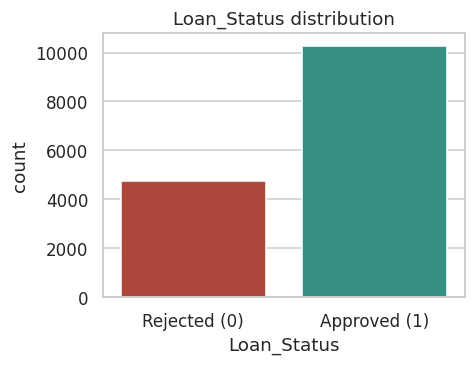

In [7]:
counts = df[TARGET].value_counts().sort_index()
print((counts / len(df) * 100).round(1).rename({0: "Rejected %", 1: "Approved %"}))
fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.countplot(x=TARGET, data=df, ax=ax, palette=["#c0392b", "#2a9d8f"])
ax.set_xticklabels(["Rejected (0)", "Approved (1)"])
ax.set_title("Loan_Status distribution")
plt.tight_layout()
plt.show()

**Observation:** about 68% of applications are approved and 32% rejected. That is a *mild* imbalance (roughly 2:1), so accuracy alone would look decent even for a weak model that always predicts "Approved" (~68%). We therefore also track precision, recall, F1 and ROC-AUC.

### 2.2 Applicant income and loan amount

Income skewness raw / log: 15.9 / 0.35


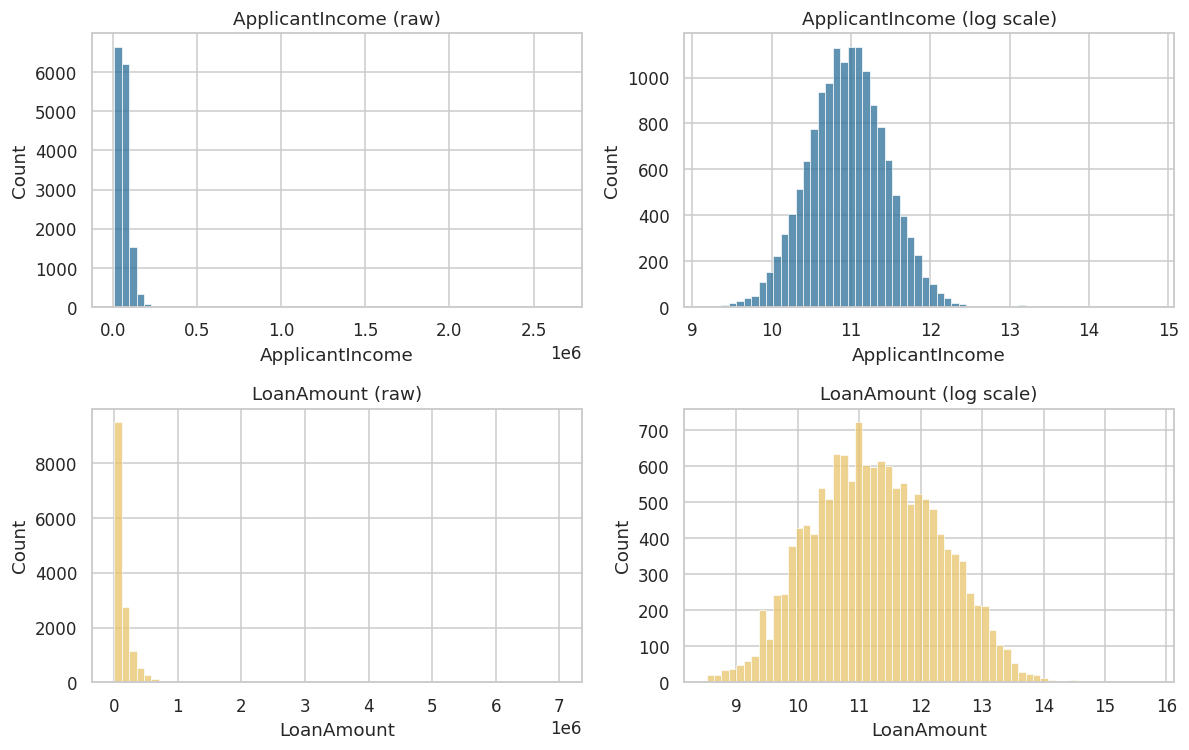

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
sns.histplot(df["ApplicantIncome"].dropna(), bins=60, ax=axes[0, 0], color="#2a6f97")
axes[0, 0].set_title("ApplicantIncome (raw)")
sns.histplot(np.log1p(df["ApplicantIncome"].dropna()), bins=60, ax=axes[0, 1], color="#2a6f97")
axes[0, 1].set_title("ApplicantIncome (log scale)")
sns.histplot(df["LoanAmount"].dropna(), bins=60, ax=axes[1, 0], color="#e9c46a")
axes[1, 0].set_title("LoanAmount (raw)")
sns.histplot(np.log1p(df["LoanAmount"].dropna()), bins=60, ax=axes[1, 1], color="#e9c46a")
axes[1, 1].set_title("LoanAmount (log scale)")
plt.tight_layout()
plt.show()
print("Income skewness raw / log:", round(df["ApplicantIncome"].skew(), 2), "/", round(np.log1p(df["ApplicantIncome"].dropna()).skew(), 2))

**Observation:** both distributions are strongly right-skewed with a few extreme values (a handful of incomes above 1 million). Extreme values would distort the scaler and linear models, which is why the pipeline clips each numeric column to its 1st-99th percentile (learned on the training data only) and includes `LogTotalIncome`.

### 2.3 Approval rate by key features

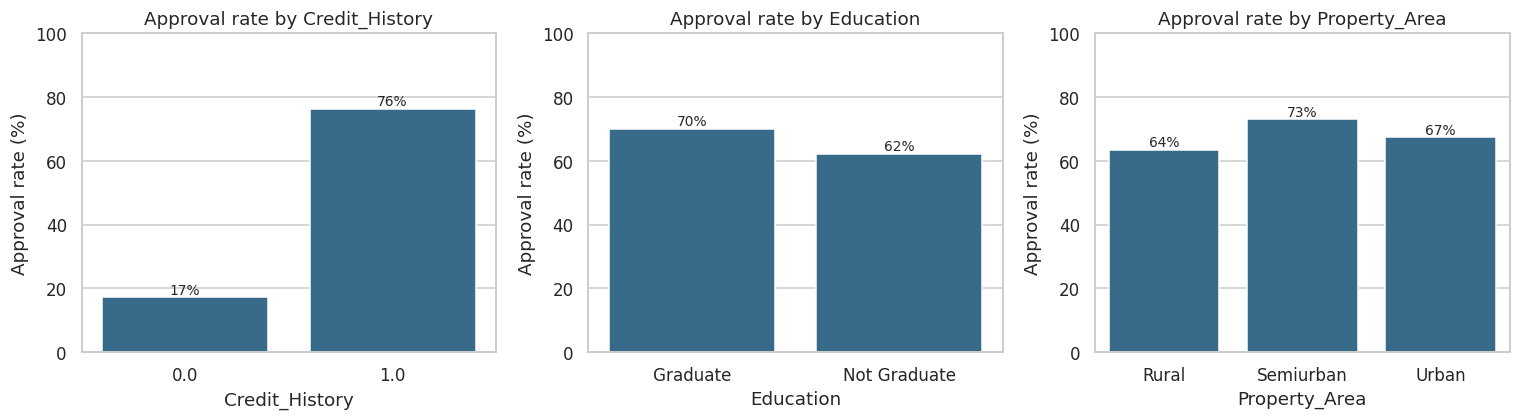

In [9]:
def approval_rate_plot(column, bins=None, ax=None, title=None):
    """Bar chart of the approval rate for each category (or numeric bin)."""
    groups = pd.cut(df[column], bins) if bins is not None else df[column]
    rates = df.groupby(groups, observed=True)[TARGET].mean().mul(100)
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, color="#2a6f97")
    ax.set_ylabel("Approval rate (%)")
    ax.set_xlabel(column)
    ax.set_ylim(0, 100)
    ax.set_title(title or f"Approval rate by {column}")
    for patch, value in zip(ax.patches, rates.values):
        ax.annotate(f"{value:.0f}%", (patch.get_x() + patch.get_width() / 2, value + 1), ha="center", fontsize=9)
    return rates

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
approval_rate_plot("Credit_History", ax=axes[0])
approval_rate_plot("Education", ax=axes[1])
approval_rate_plot("Property_Area", ax=axes[2])
plt.tight_layout()
plt.show()

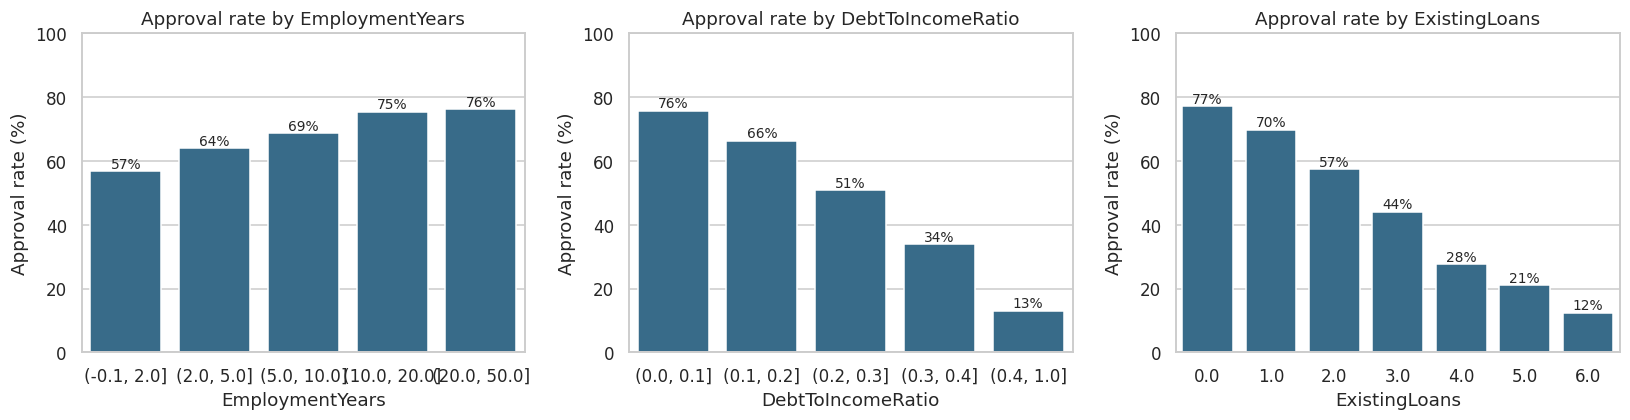

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
approval_rate_plot("EmploymentYears", bins=[-0.1, 2, 5, 10, 20, 50], ax=axes[0])
approval_rate_plot("DebtToIncomeRatio", bins=[0, 0.1, 0.2, 0.3, 0.4, 1.0], ax=axes[1])
approval_rate_plot("ExistingLoans", ax=axes[2])
plt.tight_layout()
plt.show()

**Observations (association, not causation):**

* **Credit history** is the strongest single signal: roughly 76% approval with a good history vs about 17% without.
* **Debt-to-income ratio** and **existing loans** show a steady decline: approval falls from about 76% (DTI up to 0.1) to about 13% (DTI above 0.4), and from about 77% with no existing loans to about 28% with four.
* **Employment years** has a moderate positive relationship (about 57% for 0-2 years up to about 76% for 10+ years).
* **Education** and **property area** matter less (graduates ~70% vs ~62%; semi-urban ~73% vs rural ~64%).

These are patterns in the data. In this synthetic dataset we know how the labels were generated, but on real data a pattern like this would still not prove that a feature *causes* approval.

### 2.4 Correlation of numeric features

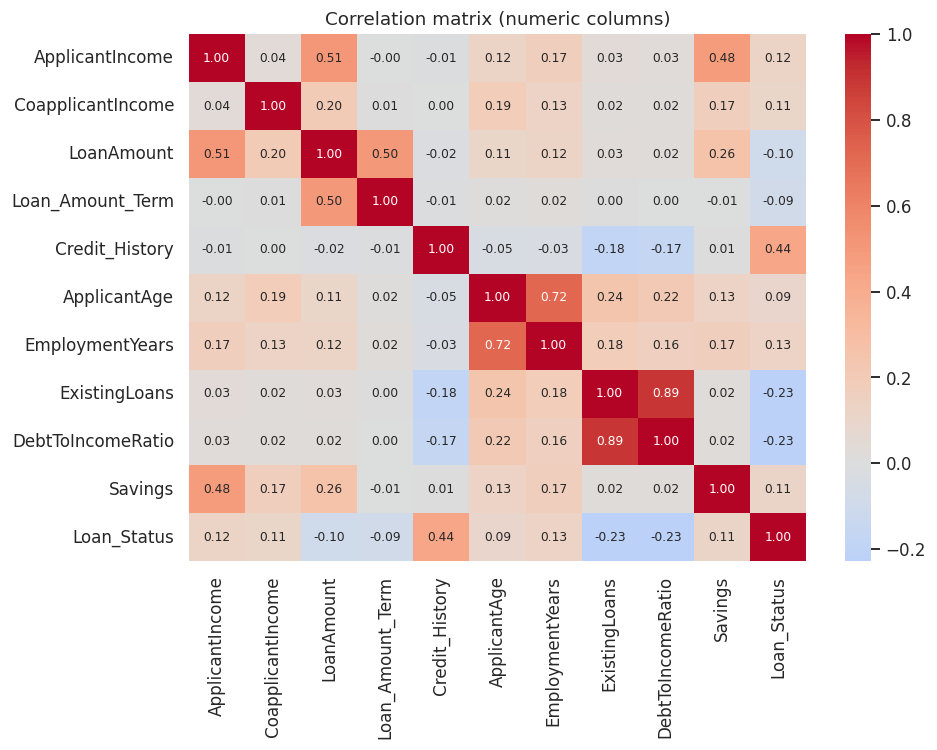

In [11]:
numeric_cols = df.select_dtypes(include="number").columns
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 8})
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()

## 3. Preprocessing and feature engineering

The pipeline in `src/features.py` does the following, **inside one scikit-learn `Pipeline`**:

1. `engineer_features` (stateless): `TotalIncome`, `MonthlyIncome`, `LogTotalIncome`, `LoanToIncomeRatio`, `EstimatedEMI`, `EMIToIncomeRatio`, `IncomePerDependent`, `SavingsToLoanRatio`, `EmploymentStability`.
2. `ColumnTransformer`
   * numeric: median imputation → percentile clipping (outliers) → `StandardScaler`
   * categorical: most-frequent imputation → `OneHotEncoder(handle_unknown="ignore")`
3. the classifier.

Because every step is fitted only on training folds / the training set, nothing is learned from the test data (**no leakage**). `Loan_Status` is never part of `X`.

In [12]:
X_train, X_test, y_train, y_test = split_data(df)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Train approval rate: %.3f | Test approval rate: %.3f" % (y_train.mean(), y_test.mean()))
assert TARGET not in X_train.columns
engineer_features(X_train.head()).iloc[:, -9:].round(3)

X_train: (12000, 17) | X_test: (3000, 17)
Train approval rate: 0.684 | Test approval rate: 0.684


,TotalIncome,MonthlyIncome,LogTotalIncome,LoanToIncomeRatio,EstimatedEMI,EMIToIncomeRatio,IncomePerDependent,SavingsToLoanRatio,EmploymentStability
11863,78000.0,6500.000,11.264,0.782,981.434,0.151,78000.0,0.815,0.734
9929,29200.0,2433.333,10.282,3.699,906.332,0.372,29200.0,0.066,0.514
724,63900.0,5325.000,11.065,0.861,1748.985,0.328,63900.0,0.824,0.400
3919,51200.0,4266.667,10.844,0.742,1208.390,0.283,51200.0,0.403,0.192
1816,81300.0,6775.000,11.306,3.948,2888.120,0.426,40650.0,0.155,0.341


## 4. Compare models (cross-validation on the training set only)

Why several metrics matter for lending:

* **Precision** (of the loans we approve, how many *should* be approved): low precision means approving risky loans → credit losses.
* **Recall** (of the good applicants, how many we approve): low recall means turning away good customers → lost business.
* **F1** balances precision and recall in one number.
* **ROC-AUC** measures how well the model *ranks* applicants regardless of the 0.5 threshold, which makes it the best primary selection metric here.
* **Accuracy** alone can be misleading when classes are imbalanced.

In [13]:
candidates = get_candidates()
comparison = compare_models(X_train, y_train, candidates)
comparison.round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (balanced),0.8148,0.8943,0.8271,0.8593,0.8873
1,Logistic Regression,0.8339,0.8501,0.9195,0.8834,0.8872
2,Gradient Boosting,0.8275,0.8434,0.9185,0.8794,0.8821
3,Random Forest,0.8272,0.8421,0.9201,0.8794,0.8762
4,Random Forest (balanced),0.8187,0.8682,0.8667,0.8674,0.8761
5,Decision Tree,0.8045,0.8240,0.9089,0.8642,0.8340


### Class imbalance

With ~68% / 32% classes the imbalance is mild, so `SMOTE` is **not justified** (it would also add an extra dependency and synthetic points that can distort probabilities). Instead the table above compares `class_weight="balanced"` variants of the same models. Weighting trades recall for precision: it makes the model more cautious about approving, which can be desirable for a lender. The weighted variants did not improve ROC-AUC, which shows the ranking quality is the same and only the decision threshold moved.

## 5. Hyperparameter tuning (`GridSearchCV`, 5-fold, training data only)

The model is selected from the cross-validation table above: highest ROC-AUC, with F1 breaking ties among models within 0.002 AUC (a gap that small is noise). Accuracy alone is never used.

In [14]:
from src.train_model import select_best_model

best_name = select_best_model(comparison)
print("Selected model:", best_name)
search = tune_model(best_name, X_train, y_train, candidates)
best_index = search.best_index_
print("Best parameters :", search.best_params_)
print("CV ROC-AUC      : %.4f" % search.cv_results_["mean_test_roc_auc"][best_index])
print("CV F1           : %.4f" % search.cv_results_["mean_test_f1"][best_index])
print("CV accuracy     : %.4f" % search.cv_results_["mean_test_accuracy"][best_index])

Selected model: Logistic Regression
Best parameters : {'model__C': 0.1, 'model__class_weight': 'balanced'}
CV ROC-AUC      : 0.8873
CV F1           : 0.8592
CV accuracy     : 0.8146


## 6. Final evaluation on the untouched test set

In [15]:
best_pipeline = search.best_estimator_
test_metrics = evaluate_pipeline(best_pipeline, X_test, y_test)
train_metrics = evaluate_pipeline(best_pipeline, X_train, y_train)

summary = pd.DataFrame({"train": train_metrics, "test": test_metrics}).drop("confusion_matrix")
print(summary.round(4))
print("\nTest confusion matrix:", test_metrics["confusion_matrix"])

              train      test
accuracy   0.816833  0.806667
precision  0.895554  0.880227
recall     0.829031  0.830492
f1         0.861009  0.854637
roc_auc    0.889515  0.877939

Test confusion matrix: {'true_negative': 715, 'false_positive': 232, 'false_negative': 348, 'true_positive': 1705}


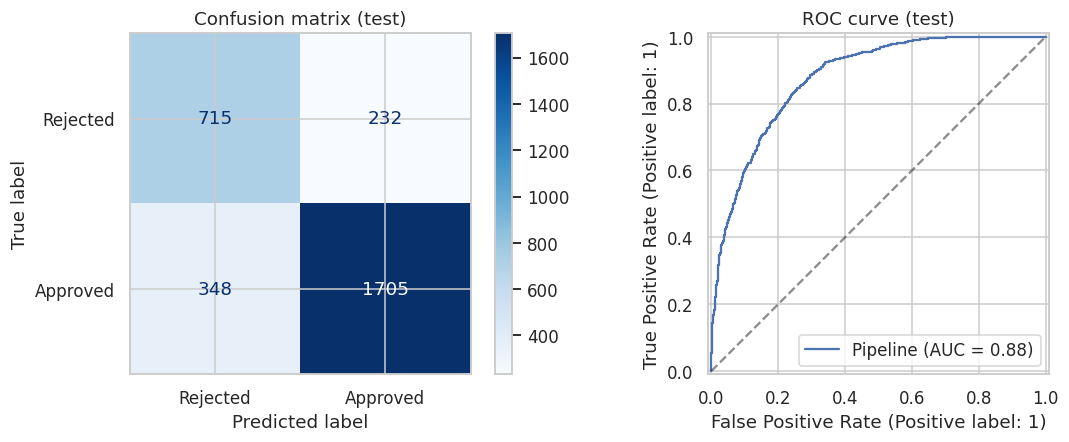

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay.from_estimator(best_pipeline, X_test, y_test, display_labels=["Rejected", "Approved"], cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix (test)")
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title("ROC curve (test)")
plt.tight_layout()
plt.show()

Train and test scores are close together, so there is no sign of overfitting. The test set was used exactly once, after all selection and tuning decisions were made on cross-validation.

## 7. Explainability

In [17]:
importance = get_model_importance(best_pipeline, top_n=12)
print(importance.round(3).to_string(index=False))

                             feature  coefficient
             numeric__Credit_History        1.257
           numeric__EMIToIncomeRatio       -0.939
             numeric__LogTotalIncome        0.629
              numeric__ExistingLoans       -0.411
          numeric__DebtToIncomeRatio       -0.373
         numeric__SavingsToLoanRatio        0.369
               numeric__ApplicantAge        0.364
categorical__Property_Area_Semiurban        0.355
        numeric__EmploymentStability        0.345
          categorical__Dependents_3+       -0.289
    categorical__Property_Area_Rural       -0.279
   categorical__LoanPurpose_Business       -0.256


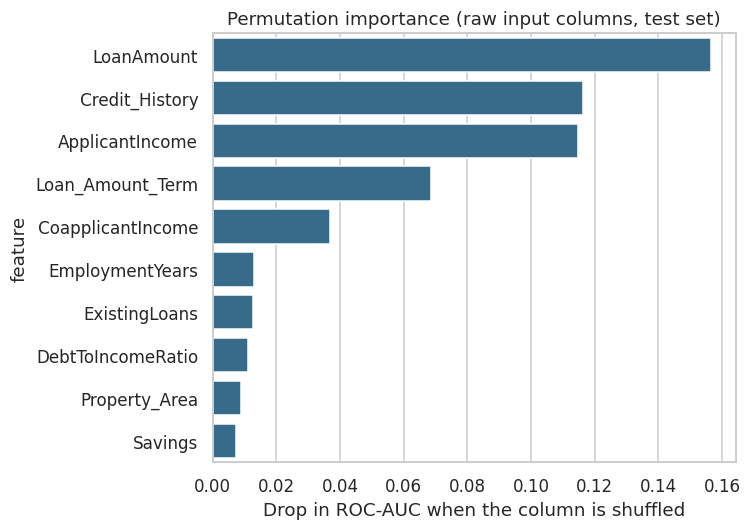

In [18]:
perm = get_permutation_importance(best_pipeline, X_test, y_test)
plt.figure(figsize=(7, 5))
sns.barplot(data=perm.head(10), x="auc_drop", y="feature", color="#2a6f97")
plt.xlabel("Drop in ROC-AUC when the column is shuffled")
plt.title("Permutation importance (raw input columns, test set)")
plt.tight_layout()
plt.show()

**Reading the results:** for the logistic regression, a positive coefficient pushes towards approval and a negative one towards rejection (inputs are standardised, so magnitudes are comparable). Credit history, EMI-to-income ratio, income, existing loans, debt-to-income ratio and savings-to-loan ratio have the strongest relationships with the prediction. These agree with the patterns seen in the EDA.

Important caveats: importance describes what the **model** uses, not what causes approvals in the real world, and correlated features (for example income and EMI ratio) share credit between them.

## 8. Check the saved model

In [19]:
import joblib
from src.config import MODEL_PATH

saved = joblib.load(MODEL_PATH)
saved_metrics = evaluate_pipeline(saved, X_test, y_test)
print("Saved model (models/loan_prediction_model.pkl) test accuracy: %.4f" % saved_metrics["accuracy"])
print("Saved model test ROC-AUC: %.4f" % saved_metrics["roc_auc"])

Saved model (models/loan_prediction_model.pkl) test accuracy: 0.8067
Saved model test ROC-AUC: 0.8779


The saved file is the complete pipeline (feature engineering + preprocessing + classifier), which the FastAPI app loads directly. Re-create it any time with `python -m src.train_model`.